# Lick Bout Plots

Loads pre-computed outputs from `4_lick_detection.py` and generates summary plots.
All figures are saved to `lick_bouts/figures/` and example 30-second windows to `lick_bouts/figures/examples/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils

In [2]:
# Configuration
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = 'exp2'
data_folder = os.path.join(data_dir, exp)

lick_bouts_dir = utils.generate_lick_bouts_path(data_dir)
figures_dir = os.path.join(lick_bouts_dir, 'figures')
examples_dir = os.path.join(figures_dir, 'examples')
os.makedirs(examples_dir, exist_ok=True)

custom_palette = {'s': '#ffb400', 'l': '#9080ff'}

In [3]:
# Load pre-computed outputs
bouts_df           = pd.read_csv(os.path.join(lick_bouts_dir, 'bouts.csv'))
session_lick_stats = pd.read_csv(os.path.join(lick_bouts_dir, 'session_lick_stats.csv'))
thresh_df          = pd.read_csv(os.path.join(lick_bouts_dir, 'mouse_thresholds.csv'))
sessions_training  = pd.read_csv(os.path.join(data_folder, f'sessions_training_{exp}.csv'))

mouse_thresholds = dict(zip(thresh_df['mouse'], thresh_df['threshold_s']))
mouse_group      = sessions_training.groupby('mouse')['group'].first().to_dict()
mice             = sorted(session_lick_stats['mouse'].unique())

def get_threshold(mouse):
    return mouse_thresholds.get(str(mouse), 0.25)

print(f'Loaded {len(bouts_df):,} bouts across {bouts_df["dir"].nunique()} sessions, '
      f'{bouts_df["mouse"].nunique()} mice')
print(f'Thresholds for {len(mouse_thresholds)} mice')

Loaded 984,211 bouts across 1925 sessions, 38 mice
Thresholds for 38 mice


## ILI Distributions

In [4]:
# Rebuild per-mouse ILI arrays from session_lick_stats + raw events
# (needed for histogram plots; only computed once here)
mouse_ilis = {}
all_ilis_list = []

for _, session_info in sessions_training.iterrows():
    mouse = session_info['mouse']
    ddir  = session_info['dir']
    # Skip sessions that were excluded from lick stats
    if ddir not in session_lick_stats['dir'].values:
        continue
    try:
        events = utils.load_data(utils.generate_events_processed_path(data_folder, session_info))
    except Exception:
        continue
    lick_events = events.loc[events['key'] == 'lick']
    session_ilis = []
    for _, blk in lick_events.groupby('block_num', sort=True):
        block_onsets = blk.loc[blk['value'] == 1, 'session_time'].sort_values().values
        if len(block_onsets) < 2:
            continue
        session_ilis.append(np.diff(block_onsets))
    if session_ilis:
        ilis = np.concatenate(session_ilis)
        all_ilis_list.append(ilis)
        mouse_ilis.setdefault(mouse, []).append(ilis)

all_ilis = np.concatenate(all_ilis_list)
for m in mouse_ilis:
    mouse_ilis[m] = np.concatenate(mouse_ilis[m])
print(f'Loaded {len(all_ilis):,} within-block ILIs')

Loaded 7,624,078 within-block ILIs


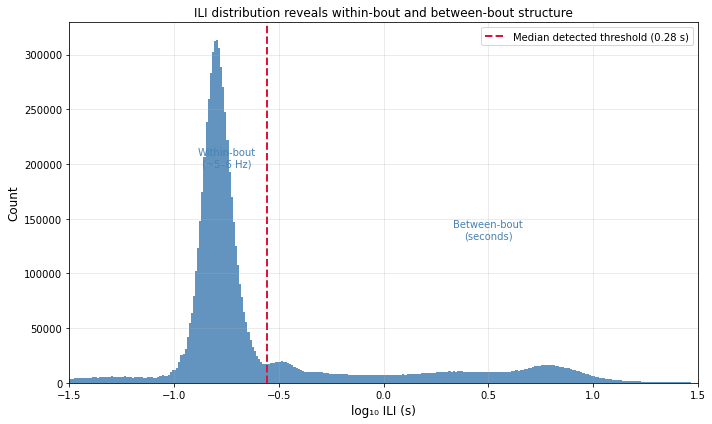

In [5]:
# Global ILI histogram
fig_g, ax_g = plt.subplots(figsize=(10, 6))
log_all = np.log10(all_ilis[(all_ilis > 0) & (all_ilis < 30)])
ax_g.hist(log_all, bins=300, range=(-1.5, 1.5), color='steelblue', edgecolor='none', alpha=0.85)
ax_g.set_xlabel('log\u2081\u2080 ILI (s)', fontsize=12)
ax_g.set_ylabel('Count', fontsize=12)
ax_g.set_title('ILI distribution reveals within-bout and between-bout structure', fontsize=12)
ax_g.set_xlim(-1.5, 1.5)
ax_g.annotate('Within-bout\n(~5\u20136 Hz)', xy=(-0.75, ax_g.get_ylim()[1]*0.6), ha='center', fontsize=10, color='steelblue')
ax_g.annotate('Between-bout\n(seconds)',    xy=(0.5,  ax_g.get_ylim()[1]*0.4), ha='center', fontsize=10, color='steelblue')
median_thresh = np.median(list(mouse_thresholds.values()))
ax_g.axvline(np.log10(median_thresh), color='crimson', linestyle='--', linewidth=2,
             label=f'Median detected threshold ({median_thresh:.2f} s)')
ax_g.legend(fontsize=10)
ax_g.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'global_ili_distribution.png'), dpi=150)
plt.show()

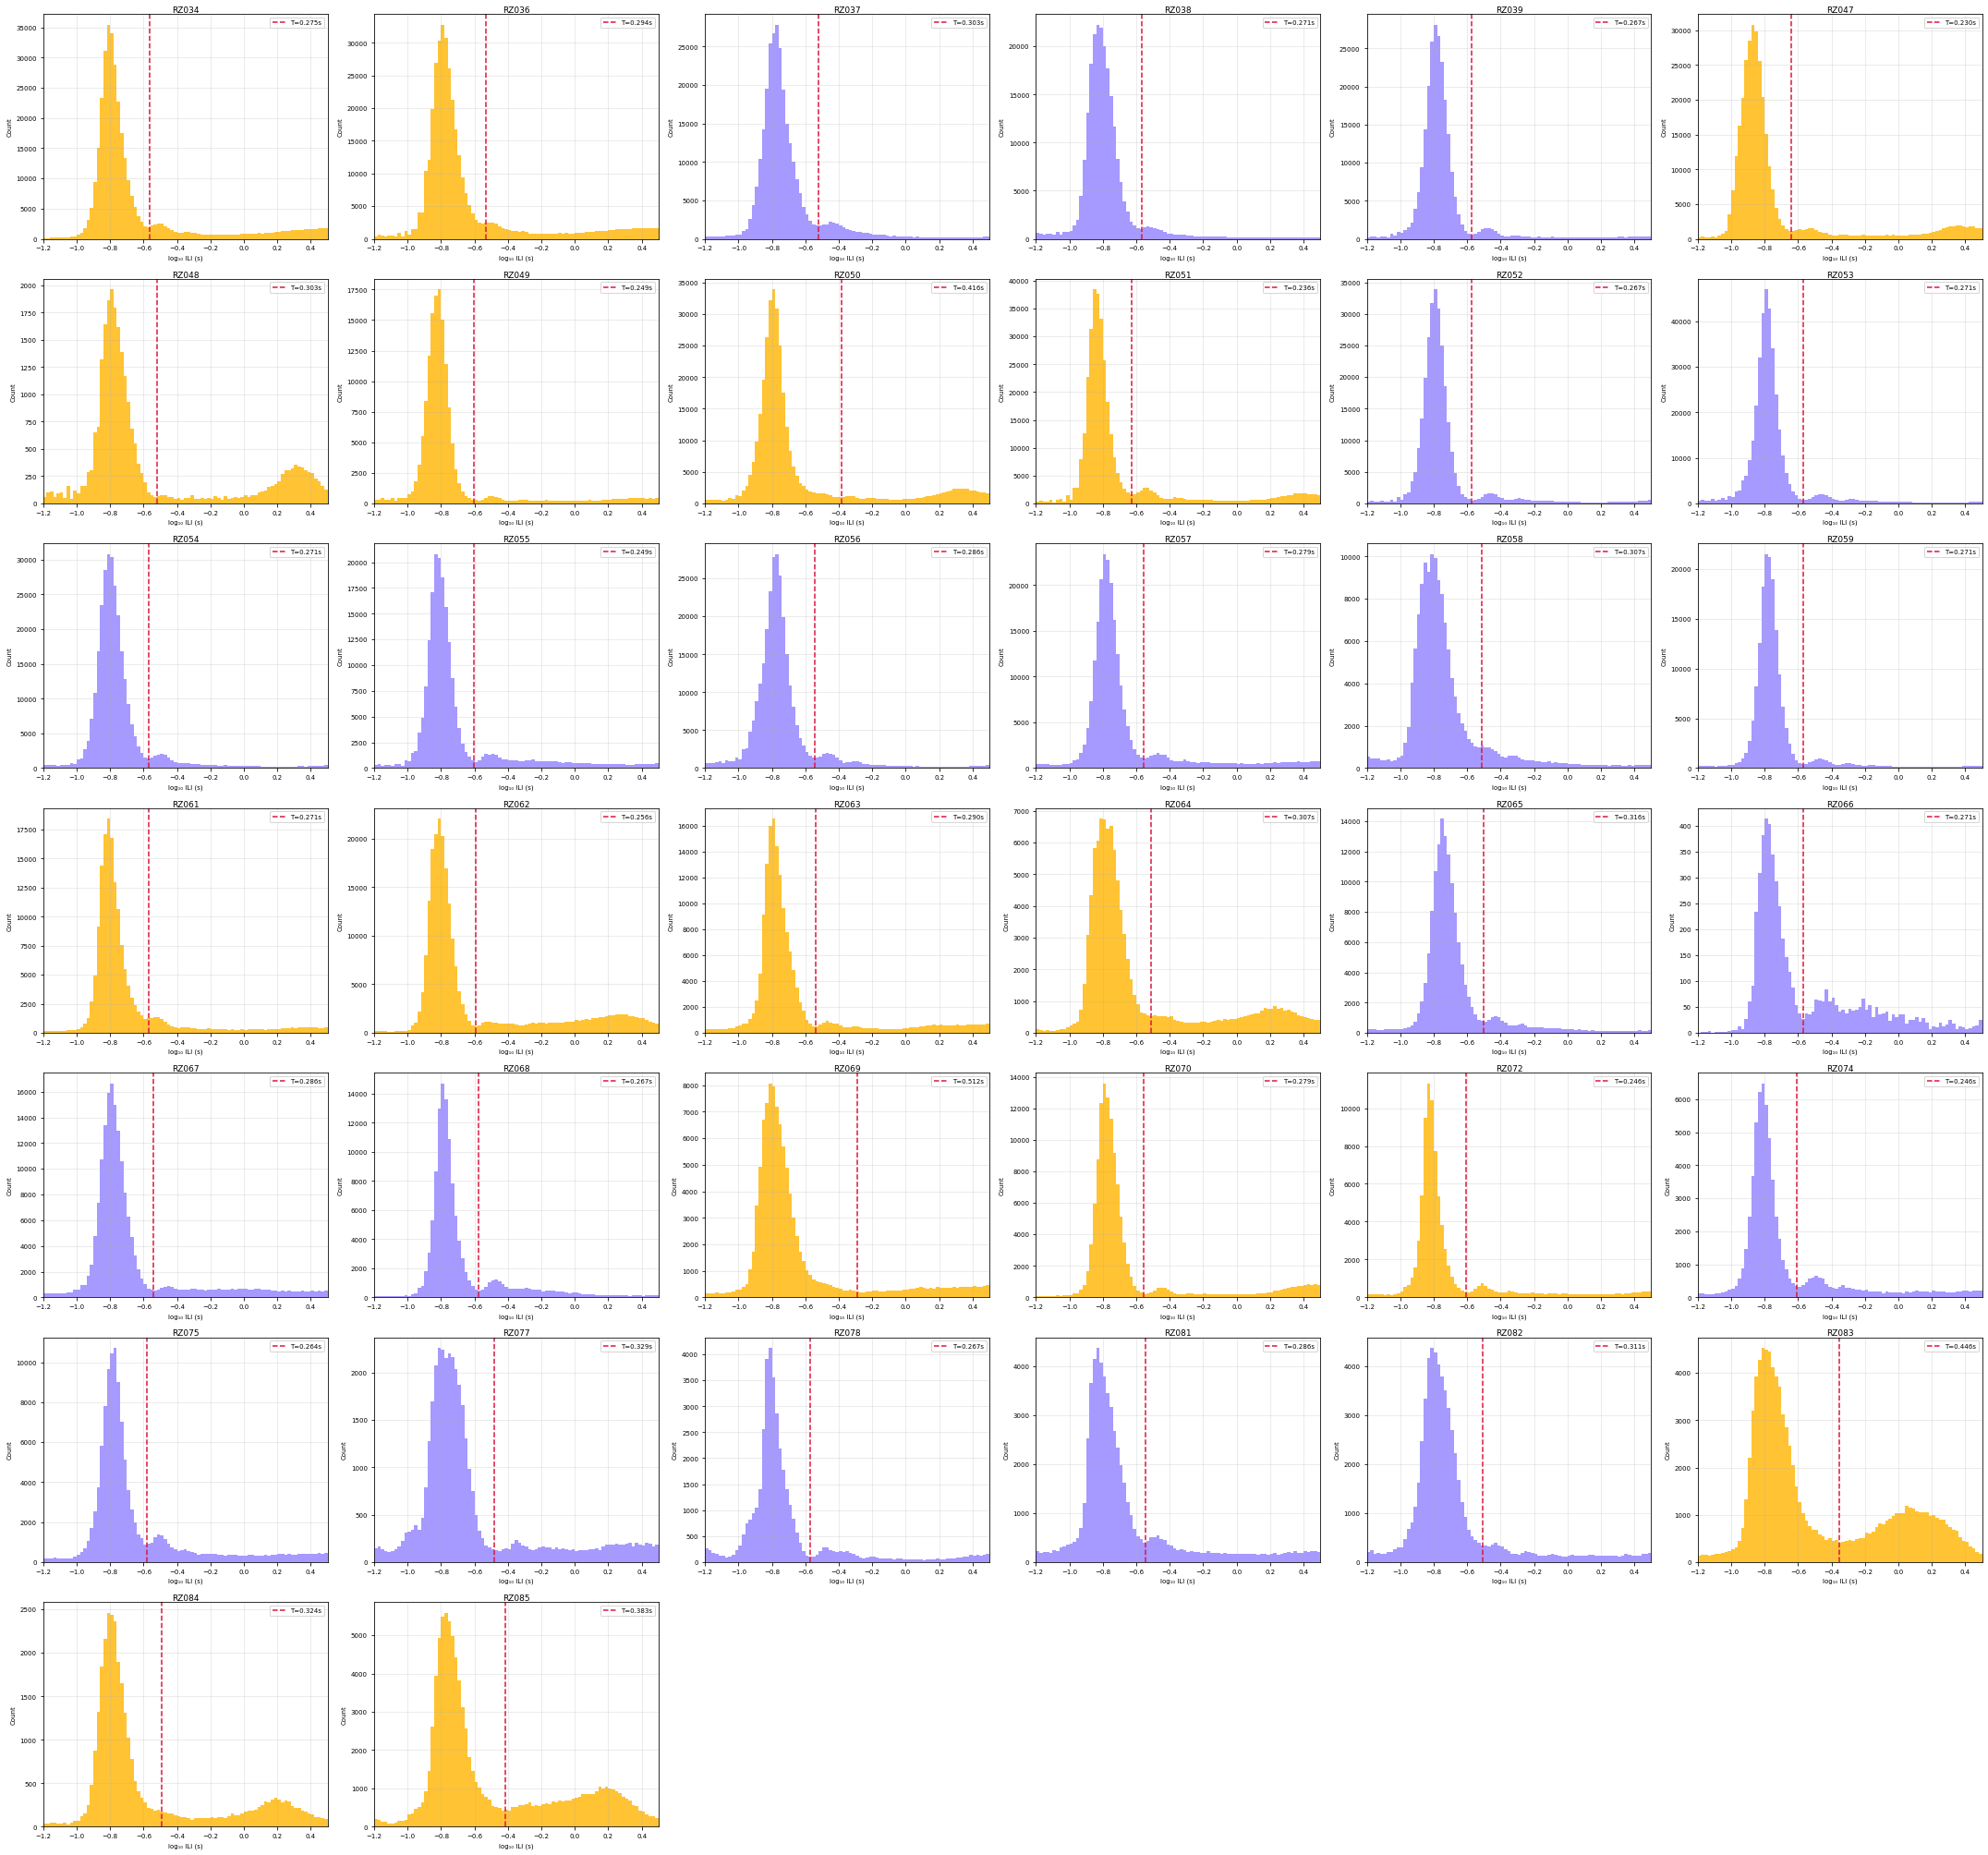

In [6]:
# Per-mouse ILI histograms with detected threshold overlay
n_cols = min(6, len(mice))
n_rows = int(np.ceil(len(mice) / n_cols))
fig_m, axes_m = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_m = np.atleast_1d(axes_m).flatten()

for i, mouse in enumerate(mice):
    ax = axes_m[i]
    ilis_m = mouse_ilis.get(mouse)
    if ilis_m is None:
        ax.axis('off')
        continue
    log_m = np.log10(ilis_m[(ilis_m > 0) & (ilis_m < 30)])
    color = custom_palette.get(mouse_group.get(mouse, 's'), '#888888')
    ax.hist(log_m, bins=150, range=(-1.5, 1.5), color=color, edgecolor='none', alpha=0.8)
    thresh = get_threshold(mouse)
    ax.axvline(np.log10(thresh), color='crimson', linestyle='--', linewidth=1.5,
               label=f'T={thresh:.3f}s')
    ax.set_xlim(-1.2, 0.5)
    ax.set_title(f'{mouse}', fontsize=9, pad=2)
    ax.set_xlabel('log\u2081\u2080 ILI (s)', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes_m)):
    axes_m[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'per_mouse_ili_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## Session Lick Statistics

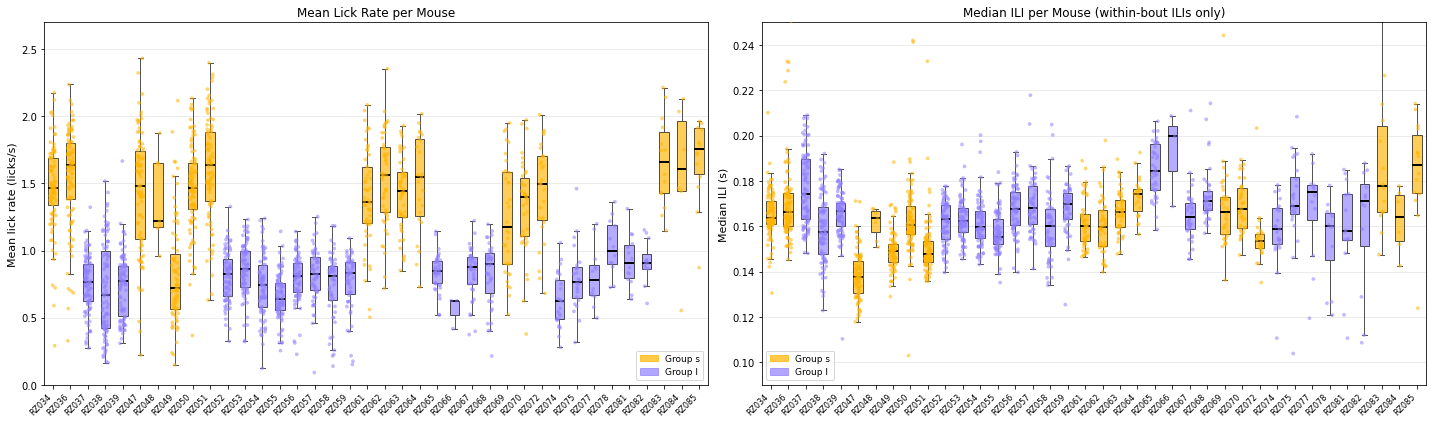

In [7]:
# Box plots: mean lick rate and median ILI per mouse, colored by group
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

metrics = [
    ('mean_lick_rate', 'Mean lick rate (licks/s)', 'Mean Lick Rate per Mouse'),
    ('median_ili',     'Median ILI (s)',            'Median ILI per Mouse (within-bout ILIs only)'),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    for i, mouse in enumerate(mice):
        grp = session_lick_stats[session_lick_stats['mouse'] == mouse]
        vals = grp[col].dropna().values
        if len(vals) == 0:
            continue
        color = custom_palette.get(mouse_group.get(mouse, 's'), '#888888')
        bp = ax.boxplot(
            vals, positions=[i], widths=0.55, patch_artist=True,
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color='#555555', linewidth=1),
            capprops=dict(color='#555555', linewidth=1),
            flierprops=dict(marker='', alpha=0),
            boxprops=dict(linewidth=1),
        )
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.65)
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(i + jitter, vals, color=color, alpha=0.55, s=14, zorder=3, edgecolors='none')
    ax.set_xticks(range(len(mice)))
    ax.set_xticklabels(mice, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7, label=f'Group {g}')
               for g, c in custom_palette.items()]
    ax.legend(handles=handles, fontsize=9)

axes[0].set_ylim(0, 2.7)
axes[1].set_ylim(0.09, 0.25)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'lick_stats_by_mouse.png'), dpi=150)
plt.show()

## Bout Validation

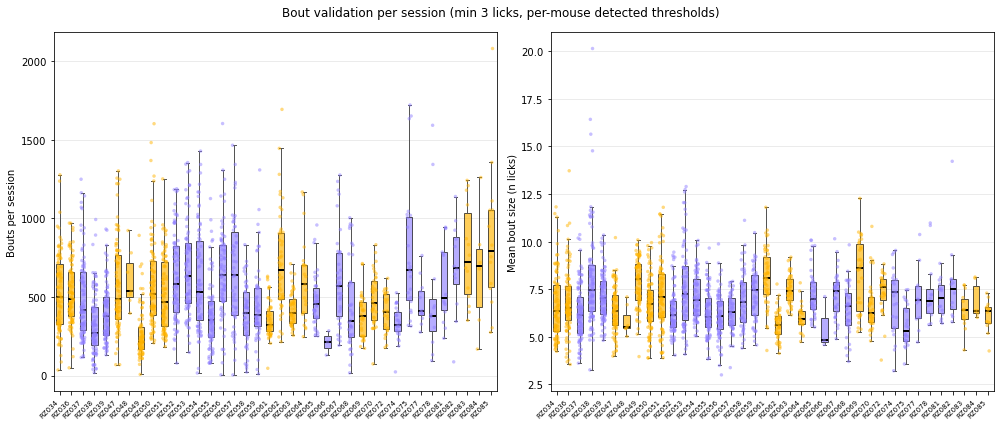

In [8]:
# Per-session bout count and mean bout size
session_val = (
    bouts_df.groupby(['mouse', 'dir'])
    .agg(
        n_bouts=('n_licks', 'count'),
        mean_bout_size=('n_licks', 'mean'),
        median_bout_size=('n_licks', 'median'),
    ).reset_index()
)

rng_v = np.random.default_rng(7)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
val_metrics = [
    ('n_bouts',        'Bouts per session',        axes[0]),
    ('mean_bout_size', 'Mean bout size (n licks)',  axes[1]),
]
for col, ylabel, ax in val_metrics:
    for i, mouse in enumerate(mice):
        grp = session_val[session_val['mouse'] == mouse]
        vals = grp[col].dropna().values
        if len(vals) == 0:
            continue
        color = custom_palette.get(mouse_group.get(mouse, 's'), '#888888')
        bp = ax.boxplot(
            vals, positions=[i], widths=0.55, patch_artist=True,
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
            flierprops=dict(marker='', alpha=0),
        )
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.65)
        jitter = rng_v.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(i + jitter, vals, color=color, alpha=0.5, s=12, zorder=3, edgecolors='none')
    ax.set_xticks(range(len(mice)))
    ax.set_xticklabels(mice, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Bout validation per session (min 3 licks, per-mouse detected thresholds)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'bout_validation_per_session.png'), dpi=150)
plt.show()

## Bout Size Distribution & Within-Bout Lick Frequency

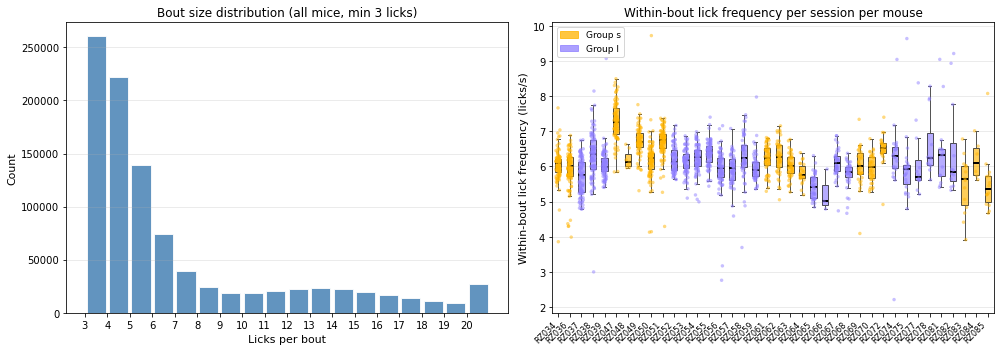

In [9]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

ax_a.hist(bouts_df['n_licks'].clip(upper=20), bins=range(3, 22),
          color='steelblue', edgecolor='white', alpha=0.85, rwidth=0.85)
ax_a.set_xlabel('Licks per bout', fontsize=11)
ax_a.set_ylabel('Count', fontsize=11)
ax_a.set_title('Bout size distribution (all mice, min 3 licks)', fontsize=12)
ax_a.set_xticks(range(3, 21))
ax_a.grid(True, alpha=0.3, axis='y')

rng_b = np.random.default_rng(5)
mice_ord = sorted(session_lick_stats['mouse'].unique())
for i, mouse in enumerate(mice_ord):
    vals = (1 / session_lick_stats.loc[session_lick_stats['mouse'] == mouse, 'median_ili']).dropna().values
    if len(vals) == 0:
        continue
    color = custom_palette.get(mouse_group.get(mouse, 's'), '#888')
    bp = ax_b.boxplot(vals, positions=[i], widths=0.55, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                      flierprops=dict(marker='', alpha=0))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.65)
    jitter = rng_b.uniform(-0.18, 0.18, size=len(vals))
    ax_b.scatter(i + jitter, vals, color=color, alpha=0.5, s=12, zorder=3, edgecolors='none')

ax_b.set_xticks(range(len(mice_ord)))
ax_b.set_xticklabels(mice_ord, rotation=45, ha='right', fontsize=8)
ax_b.set_ylabel('Within-bout lick frequency (licks/s)', fontsize=11)
ax_b.set_title('Within-bout lick frequency per session per mouse', fontsize=12)
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.75, label=f'Group {g}')
           for g, c in custom_palette.items()]
ax_b.legend(handles=handles, fontsize=9)
ax_b.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'bout_size_and_lick_freq.png'), dpi=150)
plt.show()

## Example Bouts (30-second windows)

In [10]:
import importlib.util, pathlib

_spec = importlib.util.spec_from_file_location(
    'lick_detection',
    pathlib.Path(__file__).parent / '4_lick_detection.py'
    if '__file__' in dir() else '4_lick_detection.py'
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
detect_bouts = _mod.detect_bouts

t_window = 30
n_examples = 50
rng_ex = np.random.default_rng(42)
sample_sessions = sessions_training.sample(n=n_examples, random_state=42).reset_index(drop=True)

saved = 0
for idx, session_info in sample_sessions.iterrows():
    mouse = session_info['mouse']
    ddir  = session_info['dir']
    threshold = get_threshold(mouse)
    try:
        events = utils.load_data(utils.generate_events_processed_path(data_folder, session_info))
    except Exception as e:
        print(f'Skipping {ddir}: {e}')
        continue

    ex_onsets  = events.loc[(events['key']=='lick')&(events['value']==1), 'session_time'].sort_values().values
    ex_offsets = events.loc[(events['key']=='lick')&(events['value']==0), 'session_time'].sort_values().values

    if len(ex_onsets) < 10 or (ex_onsets[-1] - ex_onsets[0]) < t_window:
        continue

    ex_bouts = detect_bouts(ex_onsets, ex_offsets, threshold=threshold, min_licks=3)
    if len(ex_bouts) == 0:
        continue

    t0 = ex_onsets[0]
    rel_onsets = ex_onsets - t0
    valid_starts = rel_onsets[rel_onsets <= rel_onsets[-1] - t_window]
    if len(valid_starts) == 0:
        continue
    t_start = rng_ex.choice(valid_starts)
    t_end = t_start + t_window

    color_cycle = [custom_palette.get(mouse_group.get(mouse, 's'), '#888'), '#aaaaaa']
    fig, ax = plt.subplots(figsize=(14, 3))

    for k, bout in enumerate(ex_bouts):
        bout_onsets = bout['lick_onsets'] - t0
        if not np.any((bout_onsets >= t_start) & (bout_onsets < t_end)):
            continue
        b_start = bout_onsets[0]
        b_end   = bout_onsets[-1] + 0.15
        ax.axvspan(max(b_start, t_start) - t_start,
                   min(b_end,   t_end)   - t_start,
                   ymin=0, ymax=1, color=color_cycle[k % 2], alpha=0.25)

    onsets_windowed = ex_onsets[(rel_onsets >= t_start) & (rel_onsets < t_end)]
    ax.vlines(onsets_windowed - t0 - t_start, 0.1, 0.9, linewidth=0.6, color='steelblue', alpha=0.9)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_yticks([])
    ax.set_xlim(0, t_window)
    ax.set_title(f'{mouse} | {ddir} | threshold={threshold:.3f}s', fontsize=9)
    ax.grid(True, alpha=0.2, axis='x')
    plt.tight_layout()

    fname = f'{saved+1:02d}_{mouse}_{ddir[:10]}.png'
    fig.savefig(os.path.join(examples_dir, fname), dpi=100)
    plt.close()
    saved += 1

print(f'Saved {saved} example bout plots to {examples_dir}')

Saved 50 example bout plots to /Users/rebekahzhang/data/behavior_data/lick_bouts/figures/examples
